Phase: Baseline Multiclass Models + Recall-Focused Evaluation + Feature Importance/Selection
Goal: Train baseline multiclass models for next-3h risk class, evaluate with recall focus, tune High-risk threshold τ, then perform feature selection using permutation importance (Option A: original features).

Input: processed_data/supervised_hood_3h_multiclass.csv
Outputs: saved models + selected feature list + chosen τ for Streamlit.

In [9]:

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score
)

import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
SUPERVISED_PATH = DATA_DIR / "supervised_baseline_3h.csv"

In [10]:

df = pd.read_csv(SUPERVISED_PATH, low_memory=False)

# Count low/medium/high (0/1/2) in y_class
counts = df["y_class"].value_counts(dropna=False).sort_index()

label_map = {0: "Low (0)", 1: "Medium (1)", 2: "High (2)"}
print("\nLabeled counts:")
print(counts.rename(index=label_map))

# Optional: percentages
pct = df["y_class"].value_counts(normalize=True, dropna=False).sort_index() * 100
print("\nPercent by class:")
print(pct.round(2))


Labeled counts:
y_class
Low (0)       1236989
Medium (1)     128361
High (2)        19836
Name: count, dtype: int64

Percent by class:
y_class
0    89.30
1     9.27
2     1.43
Name: proportion, dtype: float64


In [11]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

pct = df["y_class"].value_counts(normalize=True, dropna=False).sort_index() * 100
print("\nPercent by class:")
print(pct.round(2))

Shape: (1385186, 29)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64

Percent by class:
y_class
0    89.30
1     9.27
2     1.43
Name: proportion, dtype: float64


In [12]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (923984, 26) (228784, 26) (232418, 26)


In [13]:
# --- Identify categorical and numeric columns ---
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols), cat_cols)

Numeric: 25 Categorical: 1 ['HOOD_158_CODE']


In [16]:

# --- Preprocess: impute + scale numeric, one-hot categorical ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

In [17]:
# --- Helpers for evaluation ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
     


=== Dummy (Most Frequent) - Val ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8951    1.0000    0.9447    204791
           1     0.0000    0.0000    0.0000     20758
           2     0.0000    0.0000    0.0000      3235

    accuracy                         0.8951    228784
   macro avg     0.2984    0.3333    0.3149    228784
weighted avg     0.8013    0.8951    0.8456    228784



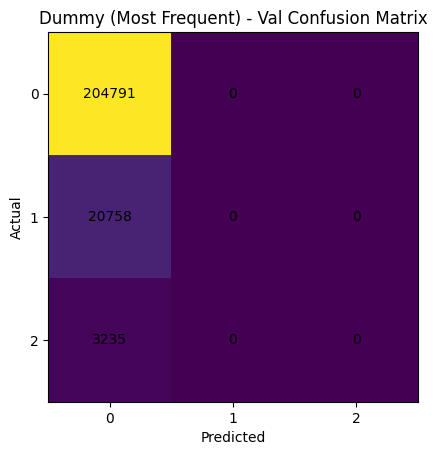

In [18]:
# --- Baseline 1: Dummy (most frequent) ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_val = dummy.predict(X_val)
eval_multiclass(y_val, pred_val, name="Dummy (Most Frequent) - Val")

c:\Users\Tanjiro\Desktop\MDA UNF\T5\Capstone project\toronto-prediction-collision\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



=== LogReg Argmax - Val ===
Per-class recall [0,1,2]: [0.6544 0.3433 0.6053]
Macro recall: 0.5343
High-risk recall: 0.6053
High-risk precision: 0.0591

               precision    recall  f1-score   support

           0     0.9518    0.6544    0.7756    204791
           1     0.1299    0.3433    0.1885     20758
           2     0.0591    0.6053    0.1077      3235

    accuracy                         0.6255    228784
   macro avg     0.3803    0.5343    0.3573    228784
weighted avg     0.8646    0.6255    0.7129    228784



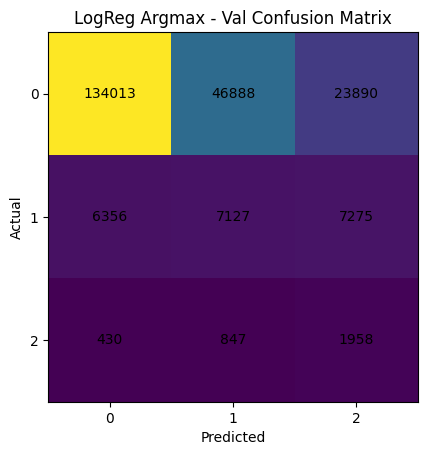


=== LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6356 0.3281 0.6766]
Macro recall: 0.5468
High-risk recall: 0.6766
High-risk precision: 0.0604

               precision    recall  f1-score   support

           0     0.9543    0.6356    0.7630    207818
           1     0.1245    0.3281    0.1806     21189
           2     0.0604    0.6766    0.1110      3411

    accuracy                         0.6081    232418
   macro avg     0.3798    0.5468    0.3515    232418
weighted avg     0.8655    0.6081    0.7003    232418



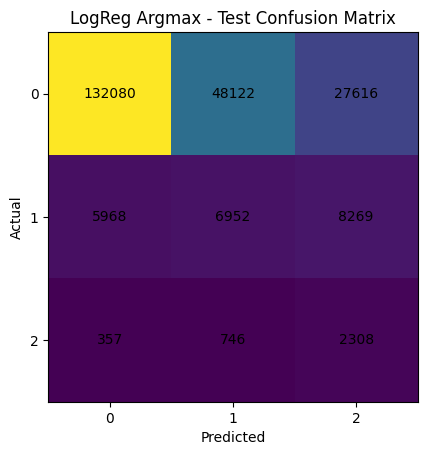

In [19]:
# --- Baseline 2: Logistic Regression (convergence fix) ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=2000,   # fix convergence
    tol=1e-3,
    n_jobs=-1,
    class_weight="balanced"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

pred_val = logreg_pipe.predict(X_val)
eval_multiclass(y_val, pred_val, name="LogReg Argmax - Val")

pred_test = logreg_pipe.predict(X_test)
eval_multiclass(y_test, pred_test, name="LogReg Argmax - Test")

        tau  high_precision  high_recall
0  0.010000        0.014445     0.999073
1  0.030256        0.015782     0.995054
2  0.050513        0.017404     0.988253
3  0.070769        0.019074     0.978671
4  0.091026        0.020696     0.965997


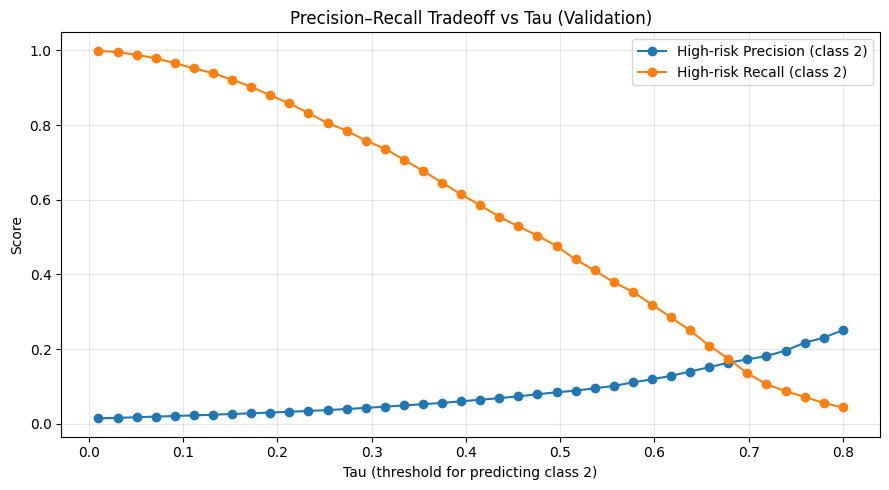

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# 1) Get predicted probabilities on validation set
proba_val = logreg_pipe.predict_proba(X_val)

# 2) Find which column corresponds to class 2 (high-risk)
classes = logreg_pipe.named_steps["model"].classes_
idx2 = int(np.where(classes == 2)[0][0])  # index for class 2

def predict_with_tau(proba, tau):
    """
    Rule:
    - If P(class2) >= tau => predict 2
    - Else => predict argmax among classes 0 and 1
    """
    # indices for class 0 and 1
    idx0 = int(np.where(classes == 0)[0][0])
    idx1 = int(np.where(classes == 1)[0][0])

    # default: choose between 0 and 1
    pred01 = np.where(proba[:, idx1] > proba[:, idx0], 1, 0)

    # override to 2 if above tau
    pred = pred01.copy()
    pred[proba[:, idx2] >= tau] = 2
    return pred

# 3) Sweep tau values and compute precision/recall for class 2
taus = np.linspace(0.01, 0.80, 40)
rows = []

y_true_high = (y_val == 2).astype(int)

for tau in taus:
    pred = predict_with_tau(proba_val, tau)
    y_pred_high = (pred == 2).astype(int)

    prec = precision_score(y_true_high, y_pred_high, zero_division=0)
    rec  = recall_score(y_true_high, y_pred_high, zero_division=0)

    rows.append({"tau": tau, "high_precision": prec, "high_recall": rec})

df_tau = pd.DataFrame(rows)

print(df_tau.head())

# 4) Plot tau vs precision and recall (tradeoff curve)
plt.figure(figsize=(9, 5))
plt.plot(df_tau["tau"], df_tau["high_precision"], marker="o", label="High-risk Precision (class 2)")
plt.plot(df_tau["tau"], df_tau["high_recall"], marker="o", label="High-risk Recall (class 2)")
plt.xlabel("Tau (threshold for predicting class 2)")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff vs Tau (Validation)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()